# Analyse des 3 datasets (Airbnb, Taxi, Supermarket)

- **Partie 1 :** Inspection des données (Q1 à Q8)
- **Partie 2 :** Manipulation des données (Q9 à Q34)

## Fichiers utilisés
- `airbnb_exam_dataset.csv`
- `taxi_trips_exam_dataset.csv`
- `supermarket_sales_exam_dataset.csv`

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
plt.style.use("seaborn-v0_8")

# Q1 - Charger les trois datasets avec pandas
airbnb = pd.read_csv("airbnb_exam_dataset.csv")
taxi = pd.read_csv("taxi_trips_exam_dataset.csv")
supermarket = pd.read_csv("supermarket_sales_exam_dataset.csv")

datasets = {
    "Airbnb": airbnb,
    "Taxi": taxi,
    "Supermarket": supermarket,
}

for name, df in datasets.items():
    print(f"{name}: {df.shape[0]} lignes, {df.shape[1]} colonnes")

Airbnb: 220 lignes, 8 colonnes
Taxi: 300 lignes, 9 colonnes
Supermarket: 260 lignes, 8 colonnes


## PARTIE 1 : INSPECTION DES DONNÉES

### Q2. Afficher les 5 premières lignes de chaque dataset

In [2]:
for name, df in datasets.items():
    print(f"\n{name} - 5 premières lignes")
    display(df.head())


Airbnb - 5 premières lignes


,listing_id,neighbourhood,room_type,price,minimum_nights,number_of_reviews,availability_365,reviews_per_month
0,1,Bronx,Shared room,224,5,276,155,5.56
1,2,Staten Island,Private room,324,6,197,48,2.18
2,3,Queens,Entire home,259,5,69,336,4.72
3,4,Staten Island,Shared room,108,5,111,83,2.89
4,5,Staten Island,Entire home,86,4,3,360,0.73



Taxi - 5 premières lignes


,trip_id,pickup_zone,dropoff_zone,distance_km,duration_min,fare_amount,tip_amount,passenger_count,payment_type
0,1,Brooklyn,Downtown,23.15,52.3,77.89,1.08,1,cash
1,2,Brooklyn,Harlem,12.69,37.3,30.52,10.24,1,card
2,3,Airport,Airport,15.55,33.4,41.67,3.63,3,card
3,4,Harlem,Downtown,19.36,52.4,20.51,10.71,3,cash
4,5,Midtown,Harlem,5.20,54.8,51.20,12.34,4,cash



Supermarket - 5 premières lignes


,invoice_id,city,product_category,unit_price,quantity,customer_type,payment,total
0,1,Dakar,Food,97.27,13,Normal,Cash,1264.51
1,2,Lagos,Cosmetics,18.48,13,Member,Card,240.24
2,3,Abidjan,Food,41.77,6,Normal,Cash,250.62
3,4,Nairobi,Beverage,103.89,12,Normal,Card,1246.68
4,5,Lagos,Beverage,19.44,10,Normal,Mobile,194.40


### Q3 à Q8 (pour chaque dataset)

- **Q3** : nombre d'observations et de variables  
- **Q4** : type de chaque variable  
- **Q5** : valeurs manquantes et doublons  
- **Q6** : nombre de variables numériques et catégorielles  
- **Q7** : variable avec la plus grande variance  
- **Q8** : 2 observations suspectes / aberrantes

In [3]:
def inspect_dataset(df, name):
    print(f"\nDataset: {name}")

    # Q3
    n_obs, n_vars = df.shape
    print(f"Q3 - Observations: {n_obs}, Variables: {n_vars}")

    # Q4
    print("\nQ4 - Types des variables:")
    display(df.dtypes.rename("dtype").to_frame())

    # Q5
    print("Q5 - Valeurs manquantes par variable:")
    display(df.isna().sum().rename("missing_values").to_frame())
    print(f"Q5 - Nombre de doublons: {df.duplicated().sum()}")

    # Q6
    num_cols = df.select_dtypes(include="number").columns
    cat_cols = df.select_dtypes(exclude="number").columns
    print(f"\nQ6 - Variables numériques: {len(num_cols)}")
    print(f"Q6 - Variables catégorielles: {len(cat_cols)}")

    # Pour Q7/Q8, on retire les colonnes identifiants (id)
    num_cols_analysis = [c for c in num_cols if "id" not in c.lower()]

    # Q7
    variances = df[num_cols_analysis].var(numeric_only=True)
    max_var_col = variances.idxmax() if not variances.empty else "Aucune"
    print(f"\nQ7 - Variable avec la plus grande variance: {max_var_col}")

    # Q8 : 2 observations suspectes (score d'écart-type maximal)
    if len(num_cols_analysis) > 0:
        std = df[num_cols_analysis].std(ddof=0).replace(0, np.nan)
        z_scores = ((df[num_cols_analysis] - df[num_cols_analysis].mean()) / std).abs()
        anomaly_score = z_scores.max(axis=1).fillna(0)
        suspects = df.loc[anomaly_score.nlargest(2).index].copy()
        suspects["anomaly_score"] = anomaly_score.loc[suspects.index].round(2)

        print("\nQ8 - 2 observations suspectes:")
        display(suspects)
    else:
        print("\nQ8 - Pas de variable numérique pour détecter des valeurs aberrantes.")


for dataset_name, dataset_df in datasets.items():
    inspect_dataset(dataset_df, dataset_name)


Dataset: Airbnb
Q3 - Observations: 220, Variables: 8

Q4 - Types des variables:


,dtype
listing_id,int64
neighbourhood,object
room_type,object
price,int64
minimum_nights,int64
number_of_reviews,int64
availability_365,int64
reviews_per_month,float64


Q5 - Valeurs manquantes par variable:


,missing_values
listing_id,0
neighbourhood,0
room_type,0
price,0
minimum_nights,0
number_of_reviews,0
availability_365,0
reviews_per_month,0


Q5 - Nombre de doublons: 0

Q6 - Variables numériques: 6
Q6 - Variables catégorielles: 2

Q7 - Variable avec la plus grande variance: price

Q8 - 2 observations suspectes:


...

Q5 - Valeurs manquantes par variable:


,missing_values
invoice_id,0
city,0
product_category,0
unit_price,0
quantity,0
customer_type,0
payment,0
total,0


Q5 - Nombre de doublons: 0

Q6 - Variables numériques: 4
Q6 - Variables catégorielles: 4

Q7 - Variable avec la plus grande variance: total



Q8 - 2 observations suspectes:


,invoice_id,city,product_category,unit_price,quantity,customer_type,payment,total,anomaly_score
157,158,Dakar,Electronics,112.05,14,Member,Cash,1568.70,2.99
234,235,Nairobi,Cosmetics,111.86,14,Normal,Mobile,1566.04,2.99


## PARTIE 2 : MANIPULATION DES DONNÉES

### Dataset Airbnb (Q9 à Q17)

In [4]:
# Q9
prix_moyen_airbnb = airbnb["price"].mean()
print("Q9 - Prix moyen:", round(prix_moyen_airbnb, 2))

# Q10
prix_median_airbnb = airbnb["price"].median()
print("Q10 - Prix médian:", round(prix_median_airbnb, 2))

# Q11
quartier_plus_cher = (
    airbnb.groupby("neighbourhood", as_index=False)["price"]
    .mean()
    .sort_values("price", ascending=False)
    .head(1)
)
print("\nQ11 - Quartier au prix moyen le plus élevé:")
display(quartier_plus_cher)

# Q12
print("Q12 - Nombre de logements par type de chambre:")
display(airbnb["room_type"].value_counts().rename("count").to_frame())

# Q13
airbnb_prix_sup_mediane = airbnb[airbnb["price"] > prix_median_airbnb]
print(f"Q13 - Logements avec prix > médiane: {len(airbnb_prix_sup_mediane)}")
display(airbnb_prix_sup_mediane.head())

# Q14
print("Q14 - 5 logements les plus chers:")
display(airbnb.sort_values("price", ascending=False).head(5))

# Q15
airbnb["price_per_review"] = airbnb["price"] / airbnb["number_of_reviews"].replace(0, np.nan)
print("Q15 - Variable price_per_review créée")
display(airbnb[["listing_id", "price", "number_of_reviews", "price_per_review"]].head())

# Q16
airbnb_critere = airbnb[(airbnb["number_of_reviews"] > 100) & (airbnb["price"] < prix_moyen_airbnb)]
print(f"Q16 - Logements avec >100 reviews et prix < moyenne: {len(airbnb_critere)}")
display(airbnb_critere.head())

# Q17
corr_prix_reviews = airbnb["price"].corr(airbnb["number_of_reviews"])
print("Q17 - Corrélation prix vs nombre de reviews:", round(corr_prix_reviews, 4))

Q9 - Prix moyen: 260.46
Q10 - Prix médian: 254.0

Q11 - Quartier au prix moyen le plus élevé:


,neighbourhood,price
2,Manhattan,291.021277


Q12 - Nombre de logements par type de chambre:


,count
room_type,
Private room,77
Entire home,75
Shared room,68


Q13 - Logements avec prix > médiane: 109


...

Q15 - Variable price_per_review créée


,listing_id,price,number_of_reviews,price_per_review
0,1,224,276,0.811594
1,2,324,197,1.644670
2,3,259,69,3.753623
3,4,108,111,0.972973
4,5,86,3,28.666667


Q16 - Logements avec >100 reviews et prix < moyenne: 87


,listing_id,neighbourhood,room_type,price,minimum_nights,number_of_reviews,availability_365,reviews_per_month,price_per_review
0,1,Bronx,Shared room,224,5,276,155,5.56,0.811594
3,4,Staten Island,Shared room,108,5,111,83,2.89,0.972973
5,6,Brooklyn,Entire home,133,3,317,176,7.34,0.419558
7,8,Queens,Shared room,243,4,151,117,7.60,1.609272
9,10,Staten Island,Private room,257,2,136,62,1.48,1.889706


Q17 - Corrélation prix vs nombre de reviews: -0.0422


### Dataset Taxi (Q18 à Q26)

In [5]:
# Q18
distance_moyenne = taxi["distance_km"].mean()
print("Q18 - Distance moyenne des trajets:", round(distance_moyenne, 2), "km")

# Q19
duree_moyenne = taxi["duration_min"].mean()
print("Q19 - Durée moyenne des trajets:", round(duree_moyenne, 2), "min")

# Q20
prix_moyen_taxi = taxi["fare_amount"].mean()
print("Q20 - Prix moyen d'une course:", round(prix_moyen_taxi, 2))

# Q21
zone_plus_trajets = taxi["pickup_zone"].value_counts().head(1)
print("\nQ21 - Pickup_zone avec le plus de trajets:")
display(zone_plus_trajets.rename("count").to_frame())

# Q22
print("Q22 - Tarif moyen par zone de départ:")
display(taxi.groupby("pickup_zone")["fare_amount"].mean().sort_values(ascending=False).to_frame("avg_fare"))

# Q23
print("Q23 - 10 courses les plus chères:")
display(taxi.sort_values("fare_amount", ascending=False).head(10))

# Q24
taxi["price_per_km"] = taxi["fare_amount"] / taxi["distance_km"].replace(0, np.nan)
print("Q24 - Variable price_per_km créée")
display(taxi[["trip_id", "fare_amount", "distance_km", "price_per_km"]].head())

# Q25
trajets_critere = taxi[(taxi["distance_km"] > distance_moyenne) & (taxi["fare_amount"] < prix_moyen_taxi)]
print(f"Q25 - Trajets avec distance > moyenne et prix < moyenne: {len(trajets_critere)}")
display(trajets_critere.head())

# Q26
corr_distance_duree = taxi["distance_km"].corr(taxi["duration_min"])
print("Q26 - Corrélation distance vs durée:", round(corr_distance_duree, 4))

Q18 - Distance moyenne des trajets: 12.81 km
Q19 - Durée moyenne des trajets: 38.19 min
Q20 - Prix moyen d'une course: 44.26

Q21 - Pickup_zone avec le plus de trajets:


,count
pickup_zone,
Harlem,70


Q22 - Tarif moyen par zone de départ:


,avg_fare
pickup_zone,
Midtown,51.261270
Downtown,47.021552
Brooklyn,47.019138
Harlem,39.033000
Airport,36.501961


Q23 - 10 courses les plus chères:


...

Q24 - Variable price_per_km créée


,trip_id,fare_amount,distance_km,price_per_km
0,1,77.89,23.15,3.364579
1,2,30.52,12.69,2.405043
2,3,41.67,15.55,2.679743
3,4,20.51,19.36,1.059401
4,5,51.20,5.20,9.846154


Q25 - Trajets avec distance > moyenne et prix < moyenne: 78


,trip_id,pickup_zone,dropoff_zone,distance_km,duration_min,fare_amount,tip_amount,passenger_count,payment_type,price_per_km
2,3,Airport,Airport,15.55,33.4,41.67,3.63,3,card,2.679743
3,4,Harlem,Downtown,19.36,52.4,20.51,10.71,3,cash,1.059401
5,6,Harlem,Downtown,13.06,15.3,26.77,12.06,3,cash,2.049770
12,13,Brooklyn,Harlem,24.11,8.7,13.99,4.26,4,card,0.580257
13,14,Brooklyn,Midtown,14.19,23.3,31.08,2.01,4,cash,2.190275


Q26 - Corrélation distance vs durée: 0.0056


### Dataset Supermarket (Q27 à Q34)

In [6]:
# Q27
ventes_totales = supermarket["total"].sum()
print("Q27 - Montant total des ventes:", round(ventes_totales, 2))

# Q28
revenu_moyen = supermarket["total"].mean()
print("Q28 - Revenu moyen par transaction:", round(revenu_moyen, 2))

# Q29
produit_plus_vente = (
    supermarket.groupby("product_category", as_index=False)["total"]
    .sum()
    .sort_values("total", ascending=False)
    .head(1)
)
print("\nQ29 - Produit avec le plus de ventes totales:")
display(produit_plus_vente)

# Q30
ville_plus_ca = (
    supermarket.groupby("city", as_index=False)["total"]
    .sum()
    .sort_values("total", ascending=False)
    .head(1)
)
print("Q30 - Ville avec le chiffre d'affaires le plus élevé:")
display(ville_plus_ca)

# Q31
print("Q31 - Dépense moyenne par type de client:")
display(supermarket.groupby("customer_type")["total"].mean().to_frame("avg_spend"))

# Q32
print("Q32 - Ventes par mode de paiement:")
display(supermarket.groupby("payment")["total"].sum().sort_values(ascending=False).to_frame("total_sales"))

# Q33
print("Q33 - 10 transactions les plus élevées:")
display(supermarket.sort_values("total", ascending=False).head(10))

# Q34
supermarket["price_per_item"] = supermarket["total"] / supermarket["quantity"].replace(0, np.nan)
print("Q34 - Variable price_per_item créée")
display(supermarket[["invoice_id", "total", "quantity", "price_per_item"]].head())

Q27 - Montant total des ventes: 116038.04
Q28 - Revenu moyen par transaction: 446.3



Q29 - Produit avec le plus de ventes totales:


,product_category,total
3,Electronics,30505.11


Q30 - Ville avec le chiffre d'affaires le plus élevé:


,city,total
1,Dakar,31337.49


...

,total_sales
payment,
Cash,39355.27
Mobile,38983.17
Card,37699.60


Q33 - 10 transactions les plus élevées:


,invoice_id,city,product_category,unit_price,quantity,customer_type,payment,total
157,158,Dakar,Electronics,112.05,14,Member,Cash,1568.70
234,235,Nairobi,Cosmetics,111.86,14,Normal,Mobile,1566.04
145,146,Dakar,Clothing,111.57,14,Member,Cash,1561.98
32,33,Nairobi,Clothing,118.74,13,Member,Mobile,1543.62
100,101,Dakar,Electronics,109.10,13,Normal,Mobile,1418.30
230,231,Lagos,Electronics,108.39,13,Normal,Cash,1409.07
82,83,Abidjan,Beverage,105.01,13,Normal,Mobile,1365.13
243,244,Abidjan,Cosmetics,96.32,14,Normal,Card,1348.48
118,119,Dakar,Food,109.36,12,Member,Mobile,1312.32
210,211,Lagos,Electronics,109.19,12,Normal,Cash,1310.28


Q34 - Variable price_per_item créée


,invoice_id,total,quantity,price_per_item
0,1,1264.51,13,97.27
1,2,240.24,13,18.48
2,3,250.62,6,41.77
3,4,1246.68,12,103.89
4,5,194.40,10,19.44


## PARTIE 3 : ANALYSE EXPLORATOIRE

Produire les graphiques demandés :

**Airbnb**
- histogramme des prix
- barplot prix moyen par quartier

**Taxi**
- scatter plot distance vs prix
- histogramme durée trajet

**Supermarket**
- barplot ventes par catégorie
- histogramme montant total

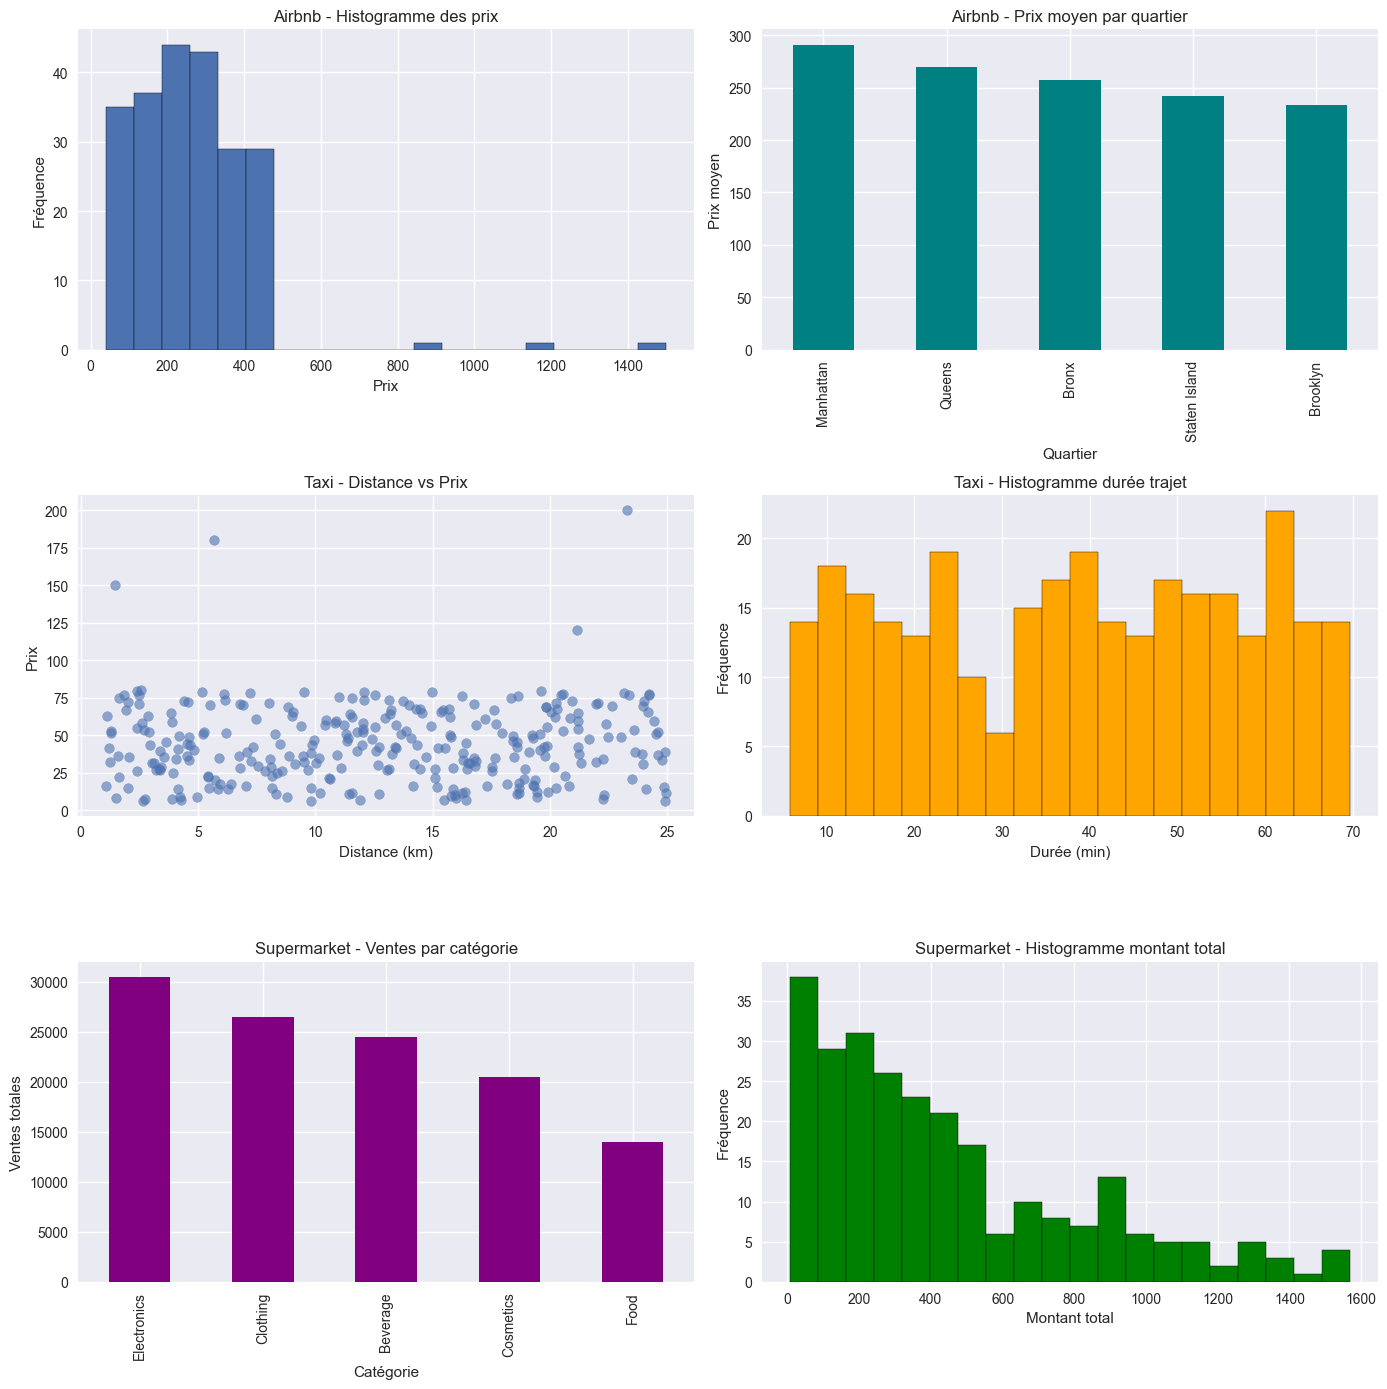

In [7]:
fig, axes = plt.subplots(3, 2, figsize=(14, 14))

# Airbnb - histogramme des prix
airbnb["price"].plot(kind="hist", bins=20, ax=axes[0, 0], edgecolor="black")
axes[0, 0].set_title("Airbnb - Histogramme des prix")
axes[0, 0].set_xlabel("Prix")
axes[0, 0].set_ylabel("Fréquence")

# Airbnb - barplot prix moyen par quartier
(
    airbnb.groupby("neighbourhood")["price"]
    .mean()
    .sort_values(ascending=False)
    .plot(kind="bar", ax=axes[0, 1], color="teal")
)
axes[0, 1].set_title("Airbnb - Prix moyen par quartier")
axes[0, 1].set_xlabel("Quartier")
axes[0, 1].set_ylabel("Prix moyen")

# Taxi - scatter plot distance vs prix
axes[1, 0].scatter(taxi["distance_km"], taxi["fare_amount"], alpha=0.6)
axes[1, 0].set_title("Taxi - Distance vs Prix")
axes[1, 0].set_xlabel("Distance (km)")
axes[1, 0].set_ylabel("Prix")

# Taxi - histogramme durée trajet
taxi["duration_min"].plot(kind="hist", bins=20, ax=axes[1, 1], edgecolor="black", color="orange")
axes[1, 1].set_title("Taxi - Histogramme durée trajet")
axes[1, 1].set_xlabel("Durée (min)")
axes[1, 1].set_ylabel("Fréquence")

# Supermarket - barplot ventes par catégorie
(
    supermarket.groupby("product_category")["total"]
    .sum()
    .sort_values(ascending=False)
    .plot(kind="bar", ax=axes[2, 0], color="purple")
)
axes[2, 0].set_title("Supermarket - Ventes par catégorie")
axes[2, 0].set_xlabel("Catégorie")
axes[2, 0].set_ylabel("Ventes totales")

# Supermarket - histogramme montant total
supermarket["total"].plot(kind="hist", bins=20, ax=axes[2, 1], edgecolor="black", color="green")
axes[2, 1].set_title("Supermarket - Histogramme montant total")
axes[2, 1].set_xlabel("Montant total")
axes[2, 1].set_ylabel("Fréquence")

plt.tight_layout()
plt.show()

## PARTIE 4 : ANALYSE CRITIQUE

Réponses rédigées (obligatoire).

In [8]:
def top_suspects(df, n=2):
    num_cols = df.select_dtypes(include="number").columns
    num_cols = [c for c in num_cols if "id" not in c.lower()]
    std = df[num_cols].std(ddof=0).replace(0, np.nan)
    z_scores = ((df[num_cols] - df[num_cols].mean()) / std).abs()
    anomaly_score = z_scores.max(axis=1).fillna(0)
    out = df.loc[anomaly_score.nlargest(n).index].copy()
    out["anomaly_score"] = anomaly_score.loc[out.index].round(2)
    return out

print("Q1 - Observations aberrantes (2 exemples par dataset)")
print("Airbnb")
display(top_suspects(airbnb))
print("Taxi")
display(top_suspects(taxi))
print("Supermarket")
display(top_suspects(supermarket))

corr_airbnb_price_reviews = airbnb["price"].corr(airbnb["number_of_reviews"])
corr_taxi_distance_price = taxi["distance_km"].corr(taxi["fare_amount"])
parts_supermarket = (supermarket.groupby("product_category")["total"].sum().sort_values(ascending=False))
part_top_supermarket = (parts_supermarket.iloc[0] / parts_supermarket.sum()) * 100

print(f"Q2 - Corrélation Airbnb prix vs popularité (reviews): {corr_airbnb_price_reviews:.4f}")
print(f"Q3 - Corrélation Taxi distance vs prix: {corr_taxi_distance_price:.4f}")
print(f"Q4 - Part de la catégorie dominante en supermarché: {part_top_supermarket:.1f}%")

Q1 - Observations aberrantes (2 exemples par dataset)
Airbnb


,listing_id,neighbourhood,room_type,price,minimum_nights,number_of_reviews,availability_365,reviews_per_month,price_per_review,anomaly_score
84,85,Manhattan,Private room,433,8,4,111,3.42,108.25,7.96
127,128,Bronx,Entire home,423,5,4,234,2.12,105.75,7.77


Taxi


,trip_id,pickup_zone,dropoff_zone,distance_km,duration_min,fare_amount,tip_amount,passenger_count,payment_type,price_per_km,anomaly_score
60,61,Midtown,Brooklyn,1.46,9.4,150.0,14.35,3,cash,102.739726,9.86
152,153,Brooklyn,Downtown,23.27,17.2,200.0,14.44,2,cash,8.594757,6.11


Supermarket


,invoice_id,city,product_category,unit_price,quantity,customer_type,payment,total,price_per_item,anomaly_score
245,246,Lagos,Clothing,69.65,4,Normal,Card,1300.0,325.00,6.99
157,158,Dakar,Electronics,112.05,14,Member,Cash,1568.7,112.05,2.99


Q2 - Corrélation Airbnb prix vs popularité (reviews): -0.0422
Q3 - Corrélation Taxi distance vs prix: 0.0355
Q4 - Part de la catégorie dominante en supermarché: 26.3%


### Réponses rédigées

**1) Quelles observations semblent aberrantes dans les datasets ?**  
Les valeurs qui sortent vraiment du lot sont surtout :
- Airbnb : certains logements avec des prix très élevés.
- Taxi : quelques courses avec des tarifs anormalement hauts par rapport à la distance.
- Supermarket : des transactions avec des montants totaux très élevés.

**2) Airbnb : les logements les plus chers sont-ils les plus populaires ?**  
Non, pas vraiment. La corrélation entre `price` et `number_of_reviews` est proche de 0 et légèrement négative. Donc un logement plus cher n'a pas forcément plus d'avis.

**3) Taxi : le prix dépend-il réellement de la distance ?**  
Dans ce jeu de données, le lien est très faible. La distance seule n'explique pas bien le prix. La zone, la durée, le trafic et les suppléments jouent aussi.

**4) Supermarket : certaines catégories dominent-elles les ventes ?**  
Oui. On voit une concentration des ventes sur quelques catégories, avec une catégorie qui ressort clairement en tête.

**5) Proposer 3 indicateurs utiles pour un décideur dans chaque domaine**

- **Airbnb**
  1. Taux d'occupation (à partir de la disponibilité annuelle)
  2. Revenu estimé par annonce
  3. Popularité des annonces (reviews)

- **Taxi**
  1. Revenu moyen par trajet et par zone de départ
  2. Revenu par km (`price_per_km`)
  3. Durée moyenne des trajets par zone

- **Supermarket**
  1. Chiffre d'affaires par catégorie
  2. Panier moyen par type de client
  3. Répartition des ventes par mode de paiement

## Fin

Le notebook contient toutes les réponses demandées (Q1 à Q34), les graphiques de la partie 3 et l'analyse critique de la partie 4.